# CSE457 — Lab 2: Đặc trưng tiếng nói và nhận dạng bằng DTW
**Lỗ Anh Việt — MSSV 2351260695**

Bài toán: nhận dạng 5 từ **không, một, hai, ba, bốn** bằng MFCC + đối sánh DTW.
Notebook thực hiện A–G, hai thí nghiệm bắt buộc và xuất WAV đã trim, hình, CSV, template, báo cáo.

**Nguồn dữ liệu được hiển thị ở ô cấu hình.** Khi `dataset/` có đủ 5 WAV/từ,
notebook dùng bộ ghi âm đó.
Nếu bộ ghi âm mới có một phần, notebook báo thiếu dữ liệu để bạn hoàn thiện.

Chọn kernel có thư viện trong `requirements.txt`, sau đó **Restart Kernel → Run All**.
Nộp toàn bộ thư mục để notebook có các module `lab2.py` và `lab2_visuals.py`.

In [1]:
from pathlib import Path
from dataclasses import replace
import csv
import json
import sys
from io import BytesIO

# Chạy khi mở tại thư mục Lab 2 hoặc thư mục gốc XuLyAmThanh.
candidates = [Path.cwd(), Path.cwd() / 'ThucHanh' / 'Lab02_2351260695_LoAnhViet']
ROOT = next((p.resolve() for p in candidates if (p / 'lab2.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Mở VS Code/Jupyter ở thư mục Lab 2 hoặc thư mục gốc dự án.')
sys.path.insert(0, str(ROOT))

import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.ndimage import median_filter
from scipy.signal import lfilter
from IPython.display import Audio, Image, Markdown, display
from lab2 import (Config, EPS, LABELS, VI_LABELS, load_audio, choose_dataset, data_source,
                  split_dataset, extract_feature, recognize, run_experiments, write_csv,
                  load_templates)
from lab2_visuals import (audit_dataset, plot_time_analysis, plot_endpoint,
                         plot_autocorrelation, plot_mel, plot_mfcc, plot_dtw,
                         plot_confusion, most_confused, write_report)

CONFIG = Config()
DATASET, OUTPUT = choose_dataset(ROOT)
OUTPUT.mkdir(parents=True, exist_ok=True)
SOURCE = data_source(DATASET)
print('Dataset:', DATASET)
print('Đầu ra:', OUTPUT)
print('Nguồn dữ liệu:', SOURCE)
print(CONFIG)
FIGURE_NUMBER = 0

def show_table(rows):
    keys = list(rows[0])
    lines = ['| ' + ' | '.join(keys) + ' |', '| ' + ' | '.join(['---'] * len(keys)) + ' |']
    for row in rows:
        values = [f'{row[k]:.4f}' if isinstance(row[k], float) else str(row[k]) for k in keys]
        lines.append('| ' + ' | '.join(values) + ' |')
    display(Markdown('\n'.join(lines)))

def show_figure(fig):
    global FIGURE_NUMBER
    # Embed PNG explicitly, including when execution uses the headless Agg backend.
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    FIGURE_NUMBER += 1
    display(Markdown(f'*Hình {FIGURE_NUMBER}. {fig.lab2_caption}*'))
    plt.close(fig)

Dataset: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet/dataset
Đầu ra: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet
Nguồn dữ liệu: phone_recordings
Config(sr=16000, frame=400, hop=160, n_fft=512, n_mels=24, n_mfcc=13, alpha=0.97, top_db=35.0, endpoint_method='adaptive', noise_window_ms=200.0, noise_on_db=8.0, noise_off_db=3.0, smooth_ms=30.0, min_speech_ms=40.0, max_gap_ms=80.0, margin_ms=200.0, endpoint=True, delta=False, cmn=True)


## A. Thu dữ liệu, kiểm tra chất lượng và chia train/test

WAV mono PCM, 16 kHz; mỗi từ tối thiểu 5 lần, có 0,2–0,5 s silence đầu/cuối.
Tên ASCII ánh xạ sang nhãn tiếng Việt. Lấy 3 file đầu/lớp làm template và các file còn lại làm test.
Chia trước mọi thí nghiệm; không dùng file test làm template.
Peak/clipping được kiểm tra trên **audio gốc**, trước chuẩn hóa.

In [2]:
split = split_dataset(DATASET)
show_table([{'label': label, 'nhãn': VI_LABELS[label],
             'train': ', '.join(p.name for p in split['train'][label]),
             'test': ', '.join(p.name for p in split['test'][label])} for label in LABELS])
quality, endpoint_rows = audit_dataset(DATASET, split, OUTPUT, CONFIG)
show_table(quality)
if any(not row['input_format_ok'] for row in quality):
    print('Có file khác mono PCM 16 kHz: pipeline chuyển mono/resample khi đọc; xem bảng kiểm tra phía trên.')
if any(row['clipping_fraction'] > 0 for row in quality):
    print('Có mẫu gần clipping: nên nghe và ghi lại nếu méo tiếng.')

| label | nhãn | train | test |
| --- | --- | --- | --- |
| khong | không | khong_01.wav, khong_02.wav, khong_03.wav | khong_04.wav, khong_05.wav |
| mot | một | mot_01.wav, mot_02.wav, mot_03.wav | mot_04.wav, mot_05.wav |
| hai | hai | hai_01.wav, hai_02.wav, hai_03.wav | hai_04.wav, hai_05.wav |
| ba | ba | ba_01.wav, ba_02.wav, ba_03.wav | ba_04.wav, ba_05.wav |
| bon | bốn | bon_01.wav, bon_02.wav, bon_03.wav | bon_04.wav, bon_05.wav |

| file | split | sr_hz | channels | subtype | duration_s | peak_original | clipping_fraction | input_format_ok |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | train | 16000 | 1 | PCM_16 | 1.6675 | 0.9387 | 0.0000 | True |
| khong/khong_02.wav | train | 16000 | 1 | PCM_16 | 1.9000 | 0.9196 | 0.0000 | True |
| khong/khong_03.wav | train | 16000 | 1 | PCM_16 | 2.0566 | 0.9179 | 0.0000 | True |
| mot/mot_01.wav | train | 16000 | 1 | PCM_16 | 1.8442 | 0.9127 | 0.0000 | True |
| mot/mot_02.wav | train | 16000 | 1 | PCM_16 | 1.7499 | 0.8077 | 0.0000 | True |
| mot/mot_03.wav | train | 16000 | 1 | PCM_16 | 1.8521 | 0.8493 | 0.0000 | True |
| hai/hai_01.wav | train | 16000 | 1 | PCM_16 | 2.1544 | 0.9353 | 0.0000 | True |
| hai/hai_02.wav | train | 16000 | 1 | PCM_16 | 1.7381 | 0.7627 | 0.0000 | True |
| hai/hai_03.wav | train | 16000 | 1 | PCM_16 | 2.0470 | 0.9117 | 0.0000 | True |
| ba/ba_01.wav | train | 16000 | 1 | PCM_16 | 2.4000 | 0.9156 | 0.0000 | True |
| ba/ba_02.wav | train | 16000 | 1 | PCM_16 | 1.7328 | 0.9114 | 0.0000 | True |
| ba/ba_03.wav | train | 16000 | 1 | PCM_16 | 1.8233 | 0.9090 | 0.0000 | True |
| bon/bon_01.wav | train | 16000 | 1 | PCM_16 | 1.9218 | 0.9088 | 0.0000 | True |
| bon/bon_02.wav | train | 16000 | 1 | PCM_16 | 2.0326 | 0.9123 | 0.0000 | True |
| bon/bon_03.wav | train | 16000 | 1 | PCM_16 | 2.2998 | 0.9064 | 0.0000 | True |
| khong/khong_04.wav | test | 16000 | 1 | PCM_16 | 1.7860 | 0.9121 | 0.0000 | True |
| khong/khong_05.wav | test | 16000 | 1 | PCM_16 | 2.4000 | 0.9139 | 0.0000 | True |
| mot/mot_04.wav | test | 16000 | 1 | PCM_16 | 1.7235 | 0.8721 | 0.0000 | True |
| mot/mot_05.wav | test | 16000 | 1 | PCM_16 | 1.9757 | 0.9093 | 0.0000 | True |
| hai/hai_04.wav | test | 16000 | 1 | PCM_16 | 2.0289 | 0.9223 | 0.0000 | True |
| hai/hai_05.wav | test | 16000 | 1 | PCM_16 | 2.3696 | 0.8762 | 0.0000 | True |
| ba/ba_04.wav | test | 16000 | 1 | PCM_16 | 2.1427 | 0.8955 | 0.0000 | True |
| ba/ba_05.wav | test | 16000 | 1 | PCM_16 | 1.8995 | 0.9109 | 0.0000 | True |
| bon/bon_04.wav | test | 16000 | 1 | PCM_16 | 1.8697 | 0.9169 | 0.0000 | True |
| bon/bon_05.wav | test | 16000 | 1 | PCM_16 | 2.0000 | 0.9213 | 0.0000 | True |

## B. Đặc trưng miền thời gian

Frame 25 ms = 400 mẫu, hop 10 ms = 160 mẫu. Frame cuối thiếu mẫu được zero-pad.
Energy, magnitude và RMS dùng frame nhân Hamming:

$$E_r=\sum_n x_r[n]^2,\quad M_r=\sum_n|x_r[n]|,\quad RMS_r=\sqrt{E_r/L}.$$

ZCR dùng frame chữ nhật, quy ước dấu tại 0 bằng +1, đếm số lần đổi dấu chia cho L.
Silence có năng lượng thấp; voiced thường energy cao và ZCR thấp hơn unvoiced.
Nhiễu nền cũng có thể có ZCR cao; không suy ra speech chỉ từ ZCR.

In [3]:
def frame_signal(y, config=Config()):
    """Frames of exactly 25 ms; zero-pad only the last incomplete frame.

    FFT padding is separate: 400-sample frames are transformed with NFFT=512.
    """
    y = np.asarray(y, dtype=float)
    if y.ndim != 1 or len(y) == 0 or not np.isfinite(y).all():
        raise ValueError("Tín hiệu phải là vector hữu hạn, không rỗng.")
    count = 1 + max(0, int(np.ceil((len(y) - config.frame) / config.hop)))
    padded = np.pad(y, (0, (count - 1) * config.hop + config.frame - len(y)))
    indices = np.arange(count)[:, None] * config.hop + np.arange(config.frame)
    return padded[indices]

def time_features(y, config=Config()):
    frames = frame_signal(y, config)
    windowed = frames * np.hamming(config.frame)
    energy = np.sum(windowed ** 2, axis=1)
    # sgn(0) = +1. Rectangular frames for ZCR, exactly crossings/L.
    signs = np.where(frames >= 0, 1, -1)
    return {
        "frames": frames,
        "time": (np.arange(len(frames)) * config.hop + config.frame / 2) / config.sr,
        "energy": energy,
        "log_energy": 10 * np.log10(energy + EPS),
        "magnitude": np.sum(np.abs(windowed), axis=1),
        "rms": np.sqrt(energy / config.frame),
        "zcr": np.sum(signs[:, 1:] != signs[:, :-1], axis=1) / config.frame,
    }

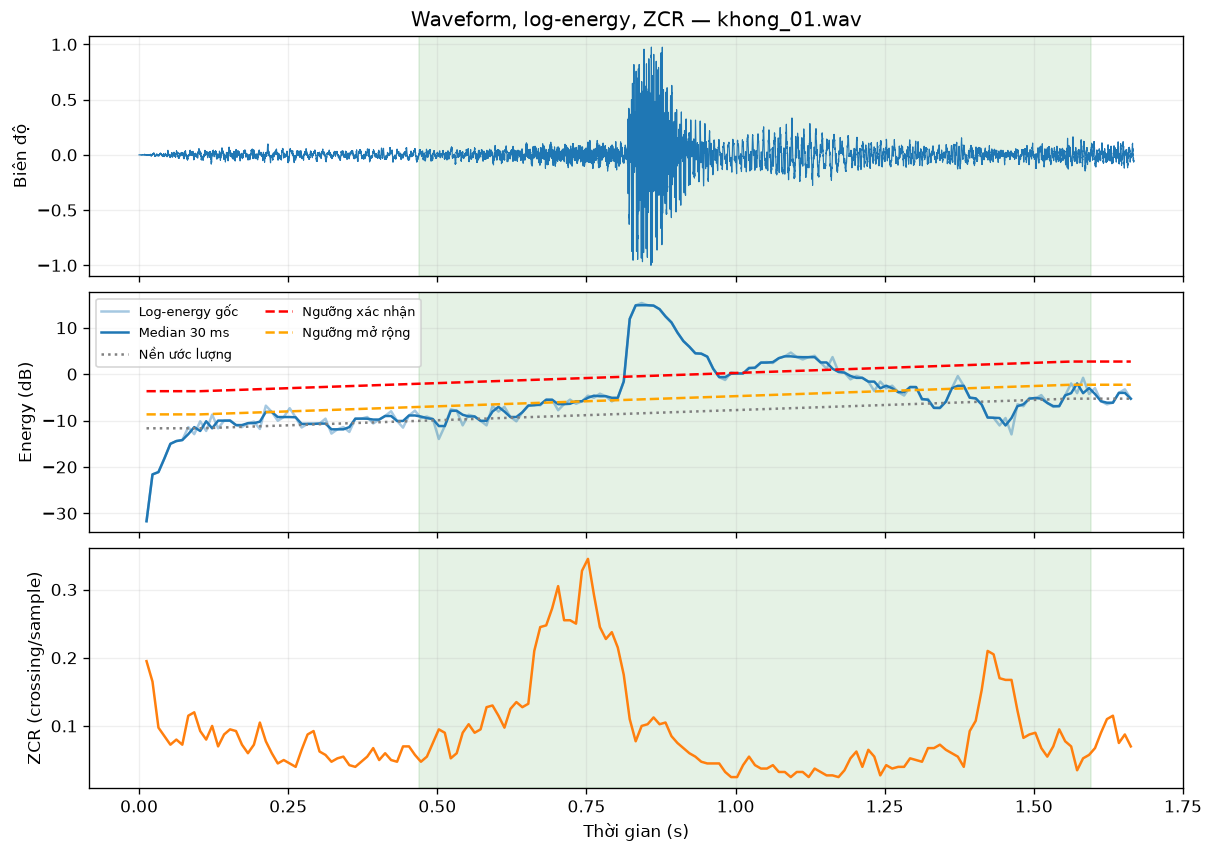

*Hình 1. Waveform, log-energy và ZCR của tệp khong_01.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*

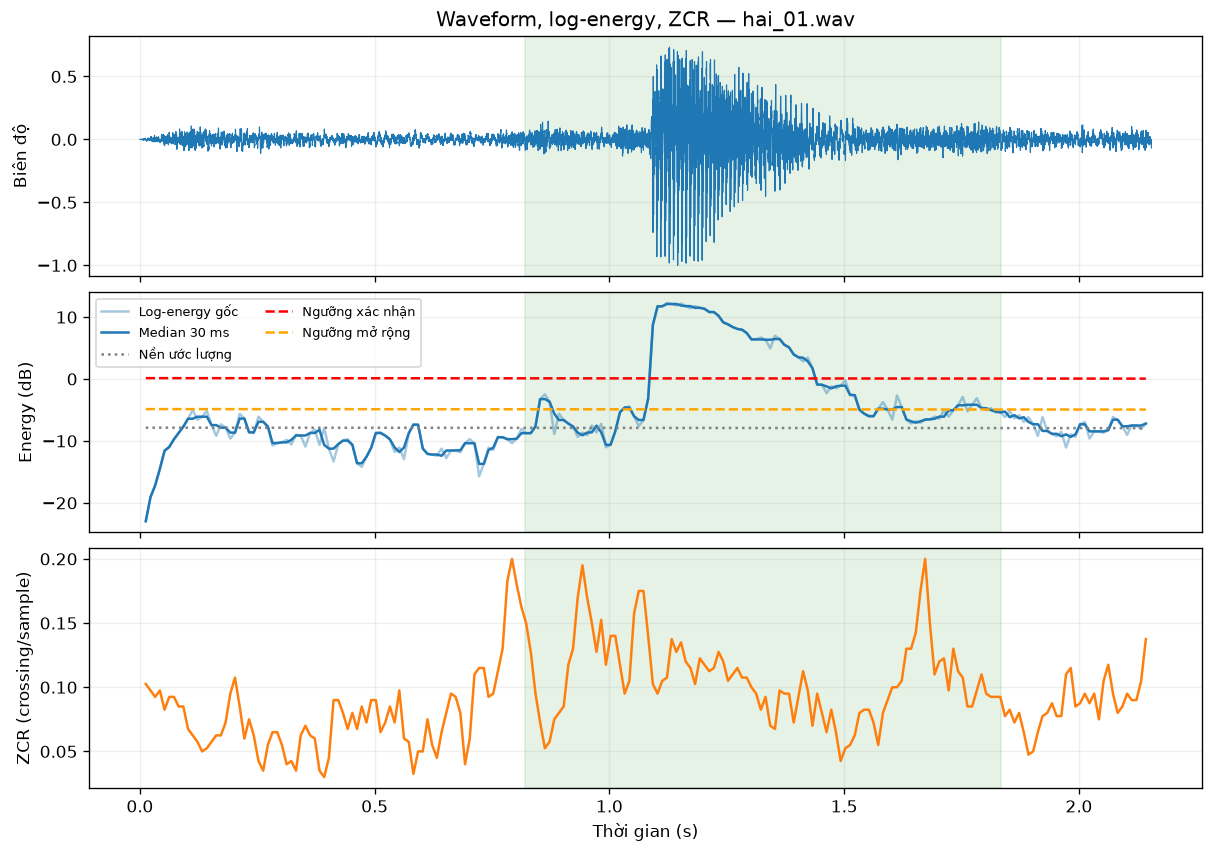

*Hình 2. Waveform, log-energy và ZCR của tệp hai_01.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*

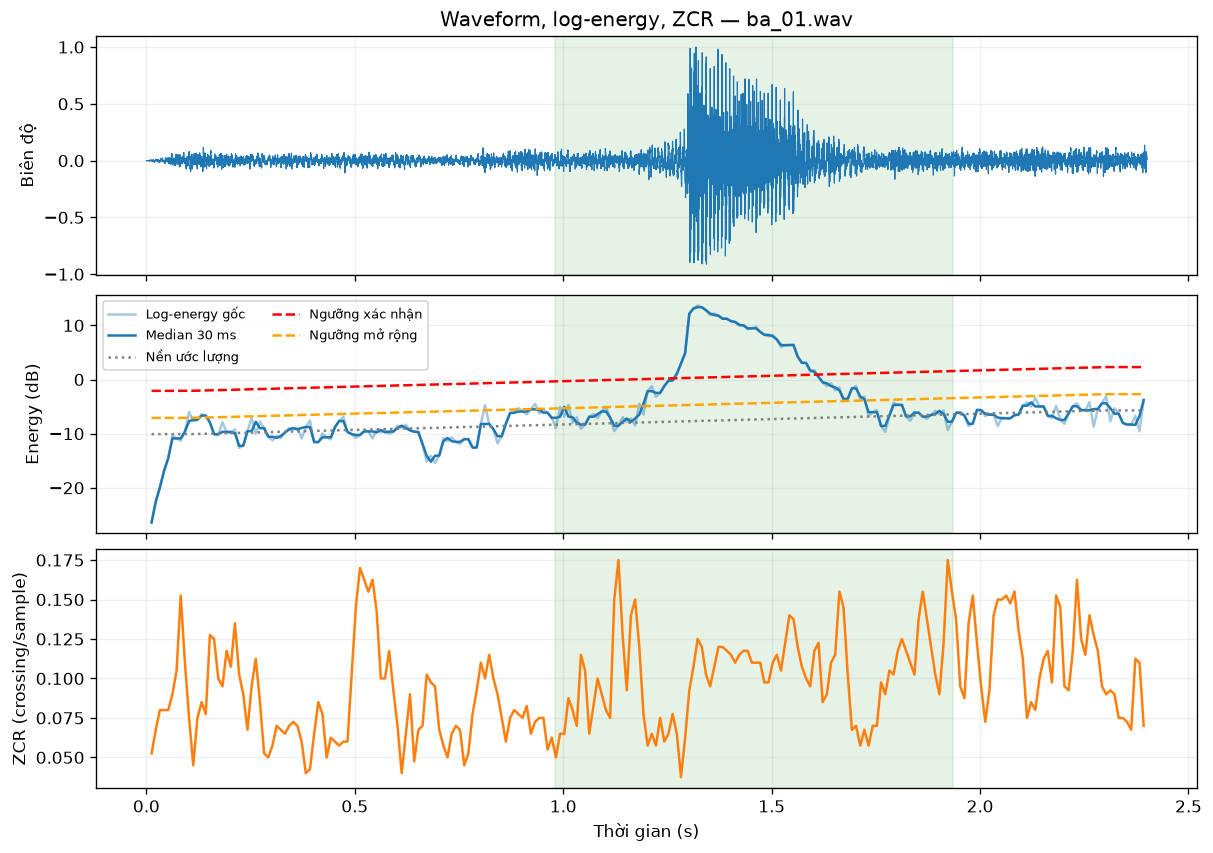

*Hình 3. Waveform, log-energy và ZCR của tệp ba_01.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*

| frame | time_s | energy | magnitude | rms | zcr |
| --- | --- | --- | --- | --- | --- |
| 0 | 0.0125 | 0.0007 | 0.3629 | 0.0013 | 0.1950 |
| 23 | 0.2425 | 0.1189 | 4.9131 | 0.0172 | 0.0500 |
| 47 | 0.4825 | 0.1219 | 5.0029 | 0.0175 | 0.0550 |
| 70 | 0.7125 | 0.2256 | 6.4502 | 0.0237 | 0.2550 |
| 94 | 0.9525 | 2.3816 | 21.1673 | 0.0772 | 0.0450 |
| 117 | 1.1825 | 1.0793 | 14.7480 | 0.0519 | 0.0350 |
| 141 | 1.4225 | 0.1162 | 4.7699 | 0.0170 | 0.2100 |
| 165 | 1.6625 | 0.2953 | 6.7330 | 0.0272 | 0.0700 |

In [4]:
for label in ('khong', 'hai', 'ba'):
    show_figure(plot_time_analysis(split['train'][label][0], OUTPUT, CONFIG))
example = time_features(load_audio(split['train']['khong'][0], CONFIG), CONFIG)
show_table([{'frame': i, 'time_s': float(example['time'][i]),
             'energy': float(example['energy'][i]), 'magnitude': float(example['magnitude'][i]),
             'rms': float(example['rms'][i]), 'zcr': float(example['zcr'][i])}
            for i in np.linspace(0, len(example['energy']) - 1, 8, dtype=int)])

## C. Endpoint detection

Ước lượng nền bằng median log-energy trong **200 ms đầu/cuối**, nội suy mức nền theo thời gian.
Làm trơn median 30 ms; ngưỡng cao **nền + 8 dB** xác nhận speech khi kéo dài ít nhất 40 ms.
Ngưỡng thấp **nền + 3 dB** mở rộng biên; nối khoảng ngắt ≤80 ms và chọn vùng có đỉnh tương phản
nền lớn nhất. Giữ **200 ms đệm** hai phía để bảo vệ âm /kh/, /h/ yếu.
Energy được tính **trước pre-emphasis**; ZCR dùng để quan sát, chưa tinh chỉnh biên bằng ZCR.

Cấu hình được chọn bằng kiểm tra biên trên 15 file train, giữ cố định trước đánh giá test.
Đối chứng với endpoint cũ (đỉnh −35 dB, margin 50 ms) được lưu cùng bảng `endpoint.csv`.
Nếu clip quá ngắn để ước lượng nền hoặc không có speech đủ tin cậy, giữ nguyên và ghi rõ trạng thái fallback.
Phương pháp giả định một từ/file và đầu/cuối chủ yếu là nền; tiếng người khác vẫn có thể làm sai biên.

In [5]:
def detect_endpoints(y, config=Config()):
    """Noise-aware endpoints for one isolated word, measured before pre-emphasis.

    Estimate background from the first/last 200 ms (assumed silence), interpolate
    to accommodate slow gain changes. Sustained high-threshold runs seed speech;
    a lower threshold preserves weak boundaries, and short gaps are bridged.
    Keep the component with greatest peak contrast and add an explicit margin.
    If silence estimates are unavailable or no sustained speech is found, retain
    the recording and report the fallback instead of inventing a speech boundary.
    ZCR is plotted, not used as a speech gate because noise also has high ZCR.
    """
    f = time_features(y, config)
    if np.max(f["energy"]) <= EPS:
        raise ValueError("Không tìm thấy tín hiệu âm thanh (file im lặng).")
    raw = f["log_energy"]
    times = f["time"]
    hop_ms = 1000 * config.hop / config.sr
    width = max(1, round(config.smooth_ms / hop_ms))
    if width % 2 == 0:
        width += 1
    smoothed = median_filter(raw, size=width, mode="nearest")
    duration = len(y) / config.sr
    window = config.noise_window_ms / 1000
    head = np.flatnonzero(times <= window)
    # Exclude the last zero-padded frame from the background estimate.
    tail = np.flatnonzero((times >= duration - window)
                         & (times + config.frame / (2 * config.sr) <= duration))
    usable_noise = duration > 2 * window and len(head) > 0 and len(tail) > 0
    if usable_noise:
        noise_start, noise_end = float(np.median(smoothed[head])), float(np.median(smoothed[tail]))
        noise = np.interp(times, [float(np.median(times[head])), float(np.median(times[tail]))],
                          [noise_start, noise_end])
    else:
        noise_start = noise_end = float(np.median(smoothed))
        noise = np.full(len(raw), noise_start)

    def runs(mask):
        edges = np.diff(np.r_[False, mask, False].astype(int))
        return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)))

    high, low = noise + config.noise_on_db, noise + config.noise_off_db
    status = "detected"
    if config.endpoint_method == "relative":
        high = np.full(len(raw), float(raw.max() - config.top_db))
        low = high.copy()
        active = np.flatnonzero(raw >= high)
        first, last = int(active[0]), int(active[-1])
    elif not usable_noise:
        first, last = 0, len(raw) - 1
        status = "too_short_for_noise_estimate"
    else:
        seeds = np.zeros(len(raw), dtype=bool)
        minimum = max(1, int(np.ceil(config.min_speech_ms / hop_ms)))
        for start, stop in runs(smoothed >= high):
            if stop - start >= minimum:
                seeds[start:stop] = True
        support = smoothed >= low
        gap = int(np.floor(config.max_gap_ms / hop_ms))
        for start, stop in runs(~support):
            if start > 0 and stop < len(support) and stop - start <= gap:
                support[start:stop] = True
        candidates = [(start, stop) for start, stop in runs(support) if seeds[start:stop].any()]
        if not candidates:
            first, last = 0, len(raw) - 1
            status = "no_confident_speech"
        else:
            start, stop = max(candidates, key=lambda span: float(np.max(
                (smoothed - noise)[span[0]:span[1]])))
            first, last = int(start), int(stop - 1)
    margin = round(config.sr * config.margin_ms / 1000)
    start = max(0, first * config.hop - margin)
    end = min(len(y), last * config.hop + config.frame + margin)
    if status == "detected":
        status = "trimmed" if start > 0 or end < len(y) else "unchanged"
    return y[start:end], {
        "start": start, "end": end,
        "first_frame": first, "last_frame": last,
        "method": config.endpoint_method, "status": status,
        "noise_db": float(np.median(noise)), "noise_start_db": noise_start, "noise_end_db": noise_end,
        "threshold_db": float(np.median(high)), "low_threshold_db": float(np.median(low)),
        "noise_curve_db": noise, "high_threshold_curve_db": high, "low_threshold_curve_db": low,
        "smoothed_log_energy": smoothed,
    }

| file | split | before_s | after_s | relative_35db_after_s | start_s | end_s | first_frame | last_frame | method | status | noise_start_db | noise_end_db | threshold_db | low_threshold_db |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| khong/khong_01.wav | train | 1.6675 | 1.1250 | 1.6675 | 0.4700 | 1.5950 | 67 | 137 | adaptive | trimmed | -11.6765 | -5.2881 | -0.4604 | -5.4604 |
| khong/khong_02.wav | train | 1.9000 | 1.3650 | 1.9000 | 0.0800 | 1.4450 | 28 | 122 | adaptive | trimmed | -5.6436 | -6.5387 | 1.9062 | -3.0938 |
| khong/khong_03.wav | train | 2.0566 | 1.2650 | 2.0566 | 0.3100 | 1.5750 | 51 | 135 | adaptive | trimmed | -9.6964 | -4.5020 | 0.9149 | -4.0851 |
| mot/mot_01.wav | train | 1.8442 | 0.7450 | 1.8442 | 0.6200 | 1.3650 | 82 | 114 | adaptive | trimmed | -8.1901 | -9.4955 | -0.8448 | -5.8448 |
| mot/mot_02.wav | train | 1.7499 | 0.7550 | 1.7499 | 0.4500 | 1.2050 | 65 | 98 | adaptive | trimmed | -8.0538 | -4.7459 | 1.6109 | -3.3891 |
| mot/mot_03.wav | train | 1.8521 | 0.9550 | 1.8521 | 0.4500 | 1.4050 | 65 | 118 | adaptive | trimmed | -5.6321 | -10.2184 | 0.0607 | -4.9393 |
| hai/hai_01.wav | train | 2.1544 | 1.0150 | 2.1544 | 0.8200 | 1.8350 | 102 | 161 | adaptive | trimmed | -7.8569 | -7.9344 | 0.1042 | -4.8958 |
| hai/hai_02.wav | train | 1.7381 | 0.9550 | 1.7381 | 0.4500 | 1.4050 | 65 | 118 | adaptive | trimmed | -9.7369 | -8.5849 | -1.1571 | -6.1571 |
| hai/hai_03.wav | train | 2.0470 | 0.9250 | 2.0470 | 0.6100 | 1.5350 | 81 | 131 | adaptive | trimmed | -5.5485 | -7.8373 | 1.3009 | -3.6991 |
| ba/ba_01.wav | train | 2.4000 | 0.9550 | 2.4000 | 0.9800 | 1.9350 | 118 | 171 | adaptive | trimmed | -10.0973 | -5.7044 | 0.1092 | -4.8908 |
| ba/ba_02.wav | train | 1.7328 | 0.8850 | 1.7328 | 0.5600 | 1.4450 | 76 | 122 | adaptive | trimmed | -4.0668 | -2.0602 | 4.9398 | -0.0602 |
| ba/ba_03.wav | train | 1.8233 | 1.0150 | 1.8233 | 0.3500 | 1.3650 | 55 | 114 | adaptive | trimmed | -9.0183 | -3.8165 | 1.5907 | -3.4093 |
| bon/bon_01.wav | train | 1.9218 | 0.8550 | 1.9218 | 0.6400 | 1.4950 | 84 | 127 | adaptive | trimmed | -12.0839 | -1.1121 | 1.4341 | -3.5659 |
| bon/bon_02.wav | train | 2.0326 | 1.3950 | 2.0326 | 0.1500 | 1.5450 | 35 | 132 | adaptive | trimmed | -7.8664 | -10.5551 | -1.2144 | -6.2144 |
| bon/bon_03.wav | train | 2.2998 | 1.7098 | 2.2998 | 0.5900 | 2.2998 | 79 | 210 | adaptive | trimmed | -7.3853 | -4.6313 | 1.9983 | -3.0017 |
| khong/khong_04.wav | test | 1.7860 | 0.9550 | 1.7860 | 0.4000 | 1.3550 | 60 | 113 | adaptive | trimmed | -7.8183 | -9.1104 | -0.4684 | -5.4684 |
| khong/khong_05.wav | test | 2.4000 | 0.9750 | 2.4000 | 0.5500 | 1.5250 | 75 | 130 | adaptive | trimmed | -9.4712 | -5.7244 | 0.4108 | -4.5892 |
| mot/mot_04.wav | test | 1.7235 | 0.7250 | 1.7235 | 0.5000 | 1.2250 | 70 | 100 | adaptive | trimmed | -6.9045 | -5.8343 | 1.6324 | -3.3676 |
| mot/mot_05.wav | test | 1.9757 | 0.7950 | 1.9757 | 0.6200 | 1.4150 | 82 | 119 | adaptive | trimmed | -8.6894 | -10.1611 | -1.4294 | -6.4294 |
| hai/hai_04.wav | test | 2.0289 | 1.2250 | 2.0289 | 0.5200 | 1.7450 | 72 | 152 | adaptive | trimmed | -9.7027 | -5.3369 | 0.4922 | -4.5078 |
| hai/hai_05.wav | test | 2.3696 | 0.9750 | 2.3696 | 0.8300 | 1.8050 | 103 | 158 | adaptive | trimmed | -1.0141 | -6.6380 | 4.1609 | -0.8391 |
| ba/ba_04.wav | test | 2.1427 | 1.2050 | 2.1427 | 0.4100 | 1.6150 | 61 | 139 | adaptive | trimmed | -6.8798 | -7.3449 | 0.8870 | -4.1130 |
| ba/ba_05.wav | test | 1.8995 | 1.0050 | 1.8995 | 0.3400 | 1.3450 | 54 | 112 | adaptive | trimmed | -5.7379 | -4.9511 | 2.6578 | -2.3422 |
| bon/bon_04.wav | test | 1.8697 | 1.0750 | 1.8697 | 0.2400 | 1.3150 | 44 | 109 | adaptive | trimmed | -0.7858 | -2.3669 | 6.4189 | 1.4189 |
| bon/bon_05.wav | test | 2.0000 | 0.8050 | 2.0000 | 0.4900 | 1.2950 | 69 | 107 | adaptive | trimmed | -0.8994 | -3.8809 | 5.6016 | 0.6016 |

| file | before_s | relative_35db_after_s | adaptive_after_s |
| --- | --- | --- | --- |
| khong/khong_01.wav | 1.6675 | 1.6675 | 1.1250 |
| khong/khong_02.wav | 1.9000 | 1.9000 | 1.3650 |
| khong/khong_03.wav | 2.0566 | 2.0566 | 1.2650 |
| mot/mot_01.wav | 1.8442 | 1.8442 | 0.7450 |
| mot/mot_02.wav | 1.7499 | 1.7499 | 0.7550 |
| mot/mot_03.wav | 1.8521 | 1.8521 | 0.9550 |
| hai/hai_01.wav | 2.1544 | 2.1544 | 1.0150 |
| hai/hai_02.wav | 1.7381 | 1.7381 | 0.9550 |
| hai/hai_03.wav | 2.0470 | 2.0470 | 0.9250 |
| ba/ba_01.wav | 2.4000 | 2.4000 | 0.9550 |
| ba/ba_02.wav | 1.7328 | 1.7328 | 0.8850 |
| ba/ba_03.wav | 1.8233 | 1.8233 | 1.0150 |
| bon/bon_01.wav | 1.9218 | 1.9218 | 0.8550 |
| bon/bon_02.wav | 2.0326 | 2.0326 | 1.3950 |
| bon/bon_03.wav | 2.2998 | 2.2998 | 1.7098 |
| khong/khong_04.wav | 1.7860 | 1.7860 | 0.9550 |
| khong/khong_05.wav | 2.4000 | 2.4000 | 0.9750 |
| mot/mot_04.wav | 1.7235 | 1.7235 | 0.7250 |
| mot/mot_05.wav | 1.9757 | 1.9757 | 0.7950 |
| hai/hai_04.wav | 2.0289 | 2.0289 | 1.2250 |
| hai/hai_05.wav | 2.3696 | 2.3696 | 0.9750 |
| ba/ba_04.wav | 2.1427 | 2.1427 | 1.2050 |
| ba/ba_05.wav | 1.8995 | 1.8995 | 1.0050 |
| bon/bon_04.wav | 1.8697 | 1.8697 | 1.0750 |
| bon/bon_05.wav | 2.0000 | 2.0000 | 0.8050 |

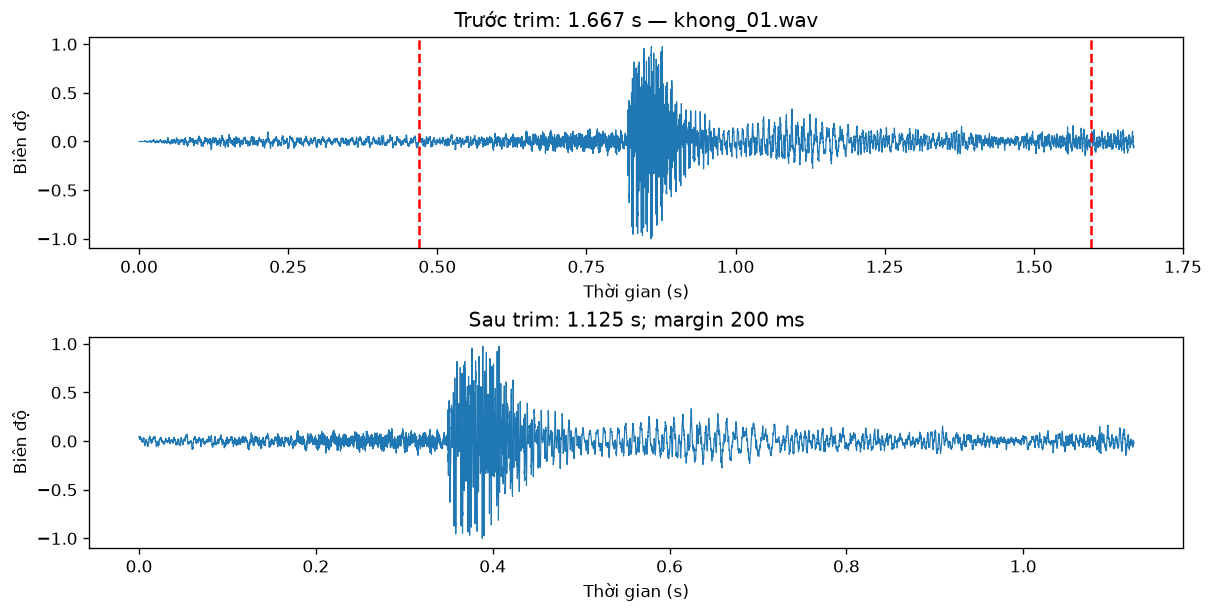

*Hình 4. So sánh waveform trước và sau endpoint của tệp khong_01.wav; hai vạch đỏ đánh dấu biên cắt, giữ đệm 200 ms mỗi phía. Panel trên là tín hiệu gốc, panel dưới là đoạn đã cắt với gốc thời gian mới; trục ngang là thời gian (s), trục dọc là biên độ chuẩn hóa.*

không: nghe trước rồi sau trim để kiểm tra mất âm đầu/cuối


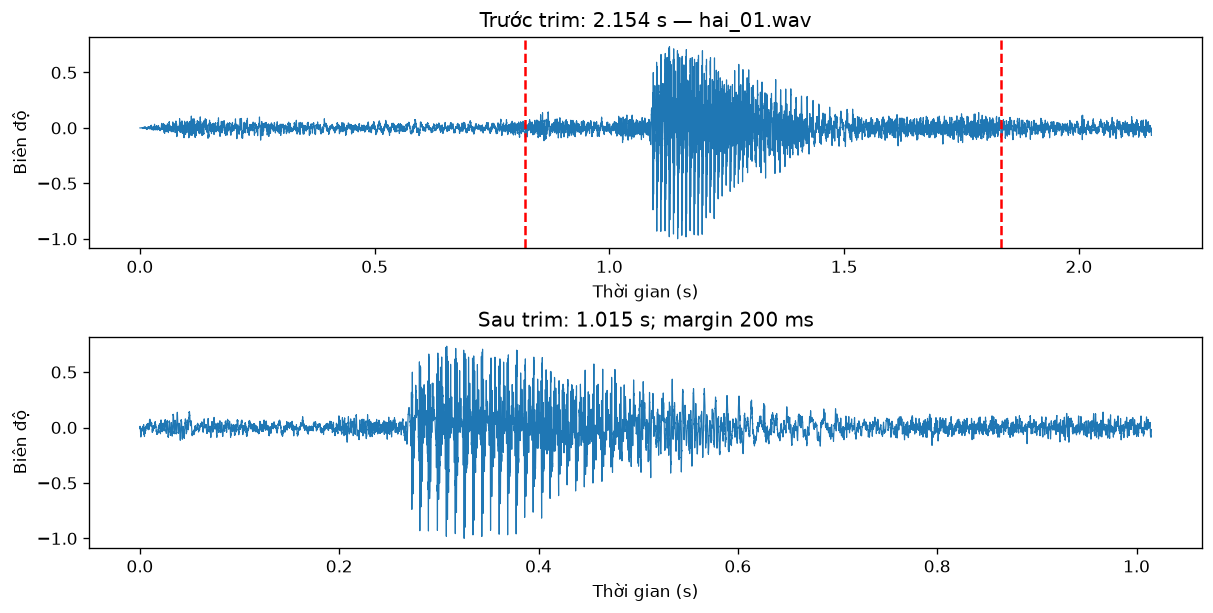

*Hình 5. So sánh waveform trước và sau endpoint của tệp hai_01.wav; hai vạch đỏ đánh dấu biên cắt, giữ đệm 200 ms mỗi phía. Panel trên là tín hiệu gốc, panel dưới là đoạn đã cắt với gốc thời gian mới; trục ngang là thời gian (s), trục dọc là biên độ chuẩn hóa.*

hai: nghe trước rồi sau trim để kiểm tra mất âm đầu/cuối


In [6]:
show_table(endpoint_rows)
show_table([{'file': row['file'], 'before_s': row['before_s'],
             'relative_35db_after_s': row['relative_35db_after_s'],
             'adaptive_after_s': row['after_s']} for row in endpoint_rows])
for label in ('khong', 'hai'):
    path = split['train'][label][0]
    show_figure(plot_endpoint(path, OUTPUT, CONFIG))
    original = load_audio(path, CONFIG)
    trimmed, _ = detect_endpoints(original, CONFIG)
    print(f'{VI_LABELS[label]}: nghe trước rồi sau trim để kiểm tra mất âm đầu/cuối')
    display(Audio(original, rate=CONFIG.sr))
    display(Audio(trimmed, rate=CONFIG.sr))

### Autocorrelation và pitch minh họa

$$R[k]=\sum_n x[n]x[n+k],\qquad F_0\approx F_s/k_0.$$

Chọn frame energy lớn nhất của “ba”, bỏ DC, nhân Hamming; tìm đỉnh trong miền tương ứng 70–400 Hz.
Không lấy lag 0. Đây là minh họa tính tuần hoàn, có thể nhầm bội/ước pitch;
không dùng pitch để nhận dạng ở bài này.

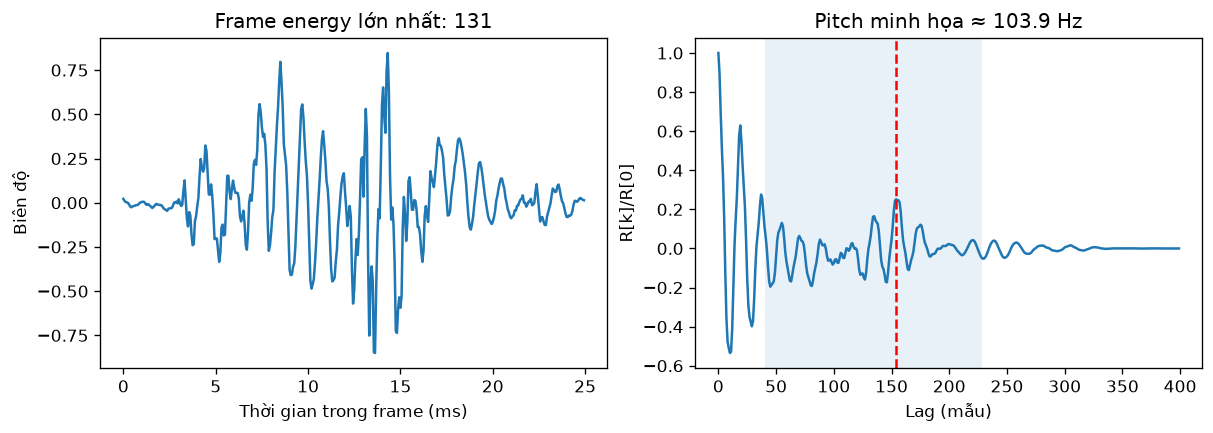

*Hình 6. Frame có energy lớn nhất của tệp ba_01.wav và tự tương quan ngắn hạn; panel trái biểu diễn frame đã bỏ DC và nhân Hamming theo thời gian (ms), panel phải biểu diễn R[k]/R[0] theo lag (mẫu). Tìm đỉnh trong miền 70–400 Hz, lag 154 mẫu cho F0 xấp xỉ 103.9 Hz.*

| file | frame | lag | pitch_hz | peak_correlation |
| --- | --- | --- | --- | --- |
| ba_01.wav | 131 | 154 | 103.8961 | 0.2517 |

In [7]:
fig, pitch_result = plot_autocorrelation(split['train']['ba'][0], OUTPUT, CONFIG)
show_figure(fig)
show_table([pitch_result])

## D. MFCC tự triển khai

Pre-emphasis α=0,97 → frame/Hamming → FFT/power → 24 Mel filters → ln → DCT-II → 13 hệ số.

$$P[k]=|FFT(x_r)[k]|^2/512,\quad S[m]=\ln(\sum_k P[k]H_m[k]+\varepsilon).$$

Thang Mel: $1125\ln(1+f/700)$. DCT-II trực chuẩn; giữ c0–c12; CMN theo utterance.
Frame thực sự dài 400 mẫu, sau đó FFT padding lên 512, tránh nhầm độ dài frame và NFFT.
Mỗi hàng feature là một frame: **shape (T,13)**. T thay đổi theo thời lượng, số chiều cố định.
Đây là một cài đặt MFCC nhất quán theo công thức đề, không yêu cầu trùng số với mặc định Librosa.

In [8]:
def mel_filterbank(config=Config()):
    hz_to_mel = lambda f: 1125 * np.log1p(f / 700)
    mel_to_hz = lambda m: 700 * np.expm1(m / 1125)
    centers = mel_to_hz(np.linspace(0, hz_to_mel(config.sr / 2), config.n_mels + 2))
    frequencies = np.fft.rfftfreq(config.n_fft, 1 / config.sr)
    filters = np.zeros((config.n_mels, len(frequencies)))
    for m in range(config.n_mels):
        left, middle, right = centers[m:m + 3]
        filters[m] = np.maximum(0, np.minimum(
            (frequencies - left) / (middle - left),
            (right - frequencies) / (right - middle)))
    return filters, frequencies

def mfcc_feature(y, config=Config()):
    """Explicit pre-emphasis -> Hamming -> FFT -> Mel -> ln -> DCT-II.

    Orthonormal DCT scaling is fixed for every utterance. Keep c0..c12.
    """
    emphasized = lfilter([1, -config.alpha], [1], y)
    frames = frame_signal(emphasized, config) * np.hamming(config.frame)
    power = np.abs(np.fft.rfft(frames, n=config.n_fft, axis=1)) ** 2 / config.n_fft
    filters, _ = mel_filterbank(config)
    log_mel = np.log(power @ filters.T + EPS)
    mfcc = dct(log_mel, type=2, norm="ortho", axis=1)[:, :config.n_mfcc]
    if config.cmn:
        mfcc -= mfcc.mean(axis=0, keepdims=True)
    if config.delta:
        # Librosa requires odd width >= 3. Very short signals have no reliable Δ.
        width = min(9, len(mfcc) if len(mfcc) % 2 else len(mfcc) - 1)
        delta = (librosa.feature.delta(mfcc.T, width=width, mode="nearest").T
                 if width >= 3 else np.zeros_like(mfcc))
        mfcc = np.concatenate([mfcc, delta], axis=1)
    return mfcc

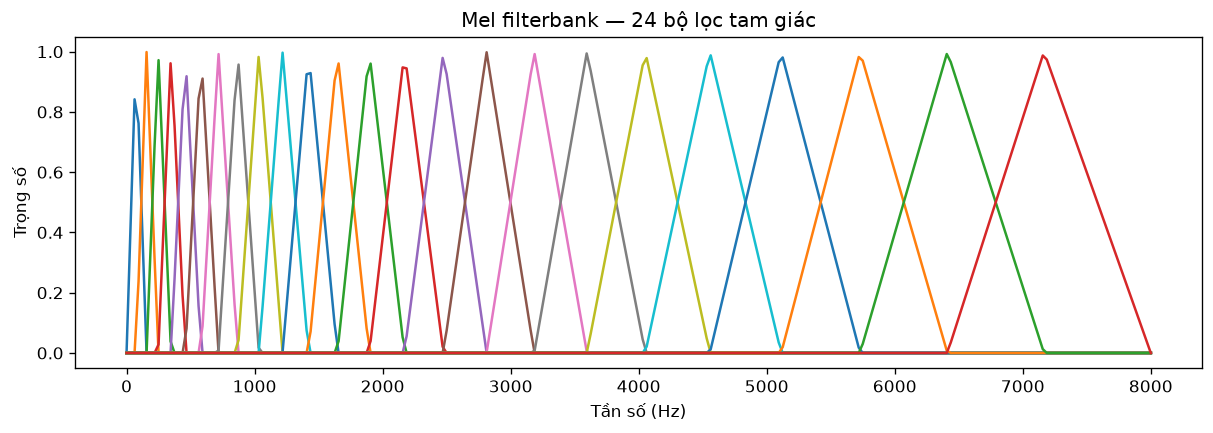

*Hình 7. Mel filterbank gồm 24 bộ lọc tam giác tại Fs = 16 kHz và NFFT = 512; trục ngang là tần số (Hz), trục dọc là trọng số. Khoảng cách theo Hz giữa các bộ lọc tăng dần ở vùng tần số cao.*

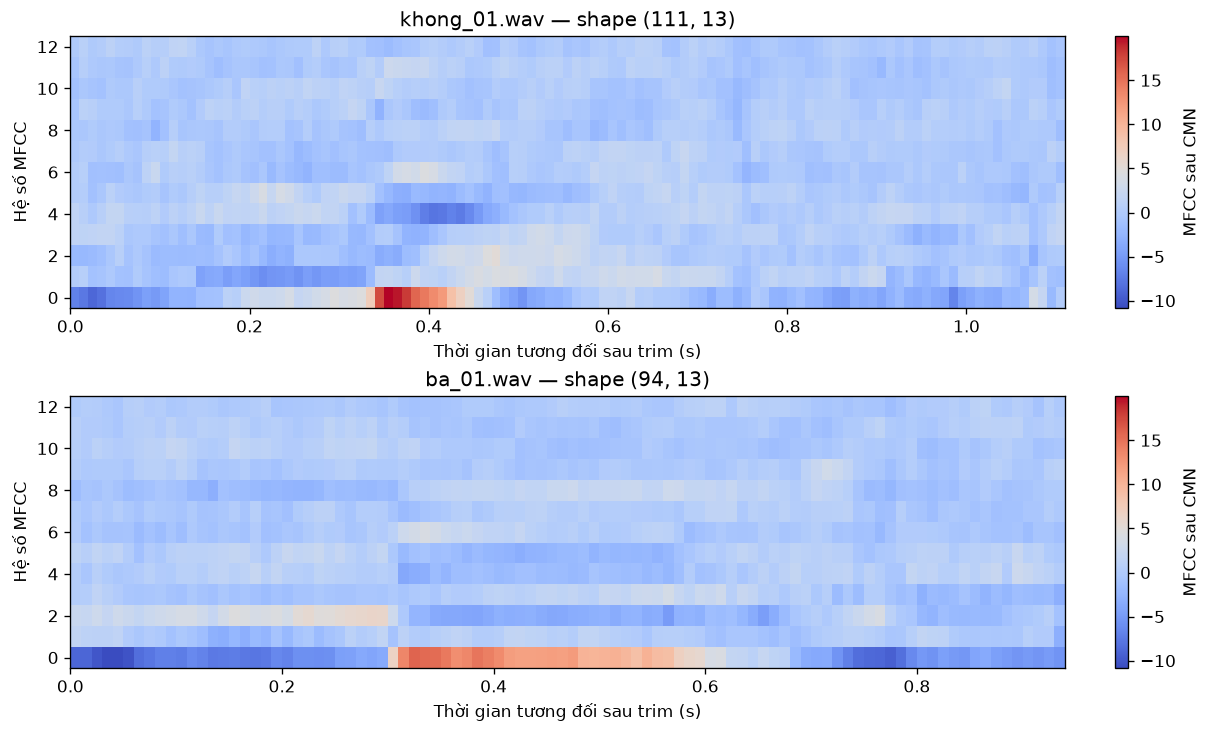

*Hình 8. Heatmap MFCC của các tệp khong_01.wav, ba_01.wav; mỗi frame có 13 hệ số và đã chuẩn hóa trung bình cepstral (CMN). Trục ngang là thời gian tương đối sau trim (s), trục dọc là chỉ số hệ số; các panel dùng chung thang màu.*

| file | shape |
| --- | --- |
| khong_01.wav | (111, 13) |
| ba_01.wav | (94, 13) |

In [9]:
show_figure(plot_mel(OUTPUT, CONFIG))
mfcc_examples = [split['train']['khong'][0], split['train']['ba'][0]]
show_figure(plot_mfcc(mfcc_examples, OUTPUT, CONFIG))
show_table([{'file': p.name, 'shape': str(extract_feature(p, CONFIG).shape)} for p in mfcc_examples])

## E. Euclidean local distance và DTW tự cài

$$C[i,j]=\|X_i-Y_j\|_2,$$
$$D[i,j]=C[i,j]+\min(D[i-1,j],D[i,j-1],D[i-1,j-1]).$$

Ma trận có biên ∞, chỉ D[0,0]=0 trong ma trận có padding. Lưu predecessor và truy vết
từ frame cuối về frame đầu. Khi hòa, ưu tiên chéo → dọc → ngang để kết quả lặp lại được.
Chuẩn hóa **sau** khi tối ưu tổng: DTW_norm = total/path length.

In [10]:
def local_distances(X, Y):
    X, Y = np.asarray(X, dtype=float), np.asarray(Y, dtype=float)
    if (X.ndim != 2 or Y.ndim != 2 or len(X) == 0 or len(Y) == 0
            or X.shape[1] != Y.shape[1] or X.shape[1] == 0
            or not np.isfinite(X).all() or not np.isfinite(Y).all()):
        raise ValueError("X/Y phải có shape (T,D), không rỗng, cùng D và hữu hạn.")
    # Each cell is Euclidean distance, not squared distance.
    return np.linalg.norm(X[:, None, :] - Y[None, :, :], axis=2)

def dtw_distance(X, Y):
    """Minimize TOTAL cost, backtrack that path, then divide by its length.

    This is the lab's normalization; it does not optimize average cost directly.
    Tie priority: diagonal, vertical, horizontal, to make paths reproducible.
    """
    C = local_distances(X, Y)
    N, M = C.shape
    D = np.full((N + 1, M + 1), np.inf)
    D[0, 0] = 0
    back = np.zeros((N, M), dtype=np.uint8)
    for i in range(1, N + 1):
        for j in range(1, M + 1):
            previous = (D[i - 1, j - 1], D[i - 1, j], D[i, j - 1])
            step = int(np.argmin(previous))
            D[i, j] = C[i - 1, j - 1] + previous[step]
            back[i - 1, j - 1] = step
    path = []
    i, j = N - 1, M - 1
    while True:
        path.append((i, j))
        if i == 0 and j == 0:
            break
        step = back[i, j]
        if step == 0:
            i, j = i - 1, j - 1
        elif step == 1:
            i -= 1
        else:
            j -= 1
    path.reverse()
    return float(D[N, M] / len(path)), path, C, D[1:, 1:]

DTW(X,X) = 0.0


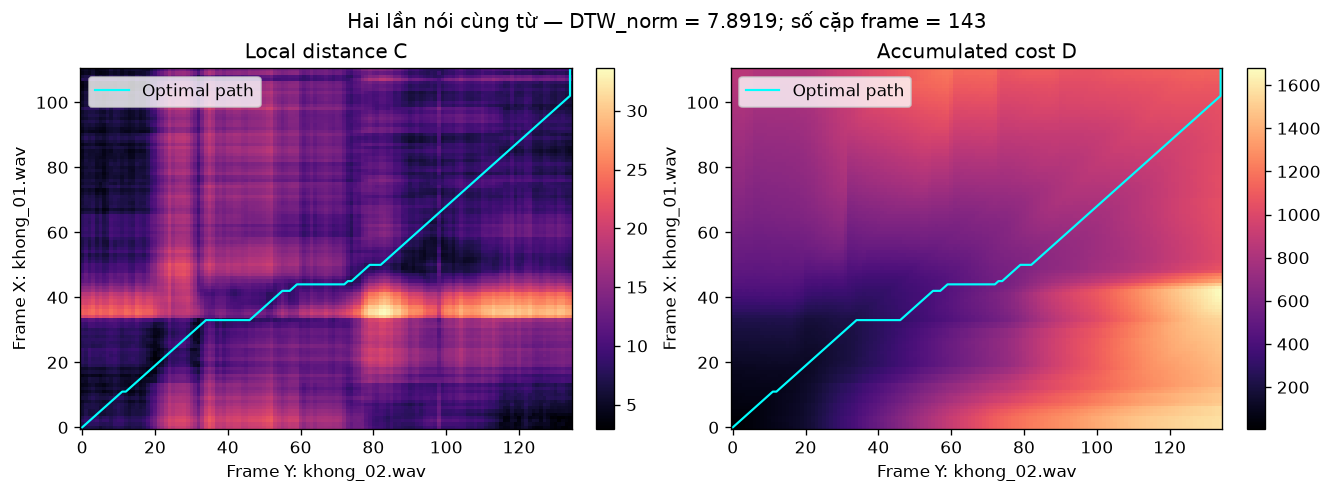

*Hình 9. Hai lần nói cùng từ: căn chỉnh DTW giữa khong_01.wav và khong_02.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*

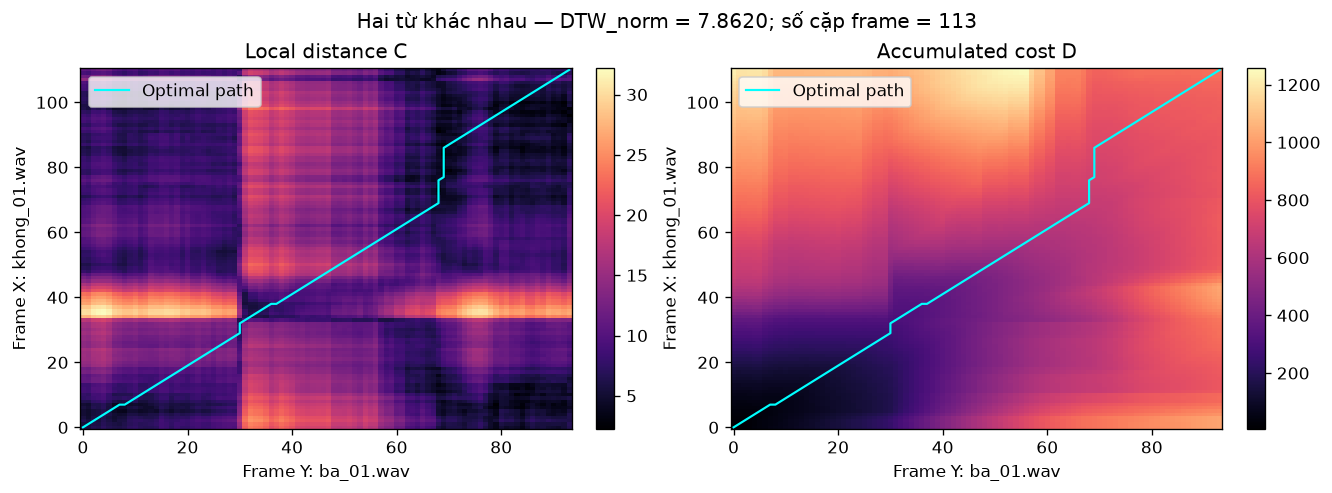

*Hình 10. Hai từ khác nhau: căn chỉnh DTW giữa khong_01.wav và ba_01.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*

| pair | file_x | file_y | frames_x | frames_y | path_length | dtw_norm |
| --- | --- | --- | --- | --- | --- | --- |
| same_word | khong_01.wav | khong_02.wav | 111 | 135 | 143 | 7.8919 |
| different_word | khong_01.wav | ba_01.wav | 111 | 94 | 113 | 7.8620 |

Cùng từ thường có score thấp hơn; cần căn cứ số đo của bộ dữ liệu hiện tại.


In [11]:
X = extract_feature(split['train']['khong'][0], CONFIG)
self_score, self_path, _, _ = dtw_distance(X, X)
assert np.isclose(self_score, 0), 'DTW(X,X) phải gần 0'
print('DTW(X,X) =', self_score)
pair_rows = []
for name, other in [('same_word', split['train']['khong'][1]),
                    ('different_word', split['train']['ba'][0])]:
    fig, row = plot_dtw(split['train']['khong'][0], other, OUTPUT, name, CONFIG)
    show_figure(fig)
    pair_rows.append(row)
show_table(pair_rows)
print('Cùng từ thường có score thấp hơn; cần căn cứ số đo của bộ dữ liệu hiện tại.')

## F–G. Nearest-template, đánh giá và hai thí nghiệm bắt buộc

Mỗi nhãn w có 3 template: $D_w(X)=\min_r DTW_{norm}(X,T_{w,r})$;
dự đoán nhãn có D_w nhỏ nhất. Top-3 gồm **nhãn** đã gộp template.

| Cấu hình | Endpoint | Feature |
|---|---|---|
| Baseline | Có | 13 MFCC |
| E1 | Không | 13 MFCC |
| E2 | Có | 13 MFCC + 13 Δ |

Giữ cùng split, vocabulary, số template và thuật toán DTW; trích lại features train/test mỗi cấu hình.
Δ dùng Librosa, cửa sổ tối đa 9 frame. Chưa dùng reject unknown và chưa có cross-speaker.

In [12]:
def build_templates(train_files, config=Config()):
    templates = {label: [extract_feature(p, config) for p in train_files[label]] for label in LABELS}
    if any(not refs for refs in templates.values()):
        raise ValueError("Mỗi nhãn cần ít nhất một template.")
    return templates

def recognize(path, templates, config=Config()):
    X = extract_feature(path, config)
    scores = {label: min(dtw_distance(X, ref)[0] for ref in templates[label]) for label in LABELS}
    ranked = sorted(scores.items(), key=lambda item: item[1])
    return ranked[0][0], dict(ranked)

| experiment | data_source | endpoint | feature_dim | correct | test_count | accuracy_percent |
| --- | --- | --- | --- | --- | --- | --- |
| baseline | phone_recordings | True | 13 | 8 | 10 | 80.0000 |
| E1_no_endpoint | phone_recordings | False | 13 | 7 | 10 | 70.0000 |
| E2_mfcc_delta | phone_recordings | True | 26 | 8 | 10 | 80.0000 |

| experiment | data_source | file | true_label | predicted_label | correct | top1_label | top1_score | top2_label | top2_score | top3_label | top3_score |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| baseline | phone_recordings | khong/khong_04.wav | khong | khong | True | khong | 4.8589 | bon | 5.8285 | mot | 5.9048 |
| baseline | phone_recordings | khong/khong_05.wav | khong | khong | True | khong | 5.2291 | bon | 6.4318 | mot | 6.6505 |
| baseline | phone_recordings | mot/mot_04.wav | mot | bon | False | bon | 4.8933 | mot | 5.2137 | khong | 6.3698 |
| baseline | phone_recordings | mot/mot_05.wav | mot | bon | False | bon | 4.8275 | mot | 5.4789 | khong | 7.0499 |
| baseline | phone_recordings | hai/hai_04.wav | hai | hai | True | hai | 4.9286 | ba | 5.7358 | bon | 6.7079 |
| baseline | phone_recordings | hai/hai_05.wav | hai | hai | True | hai | 5.4955 | ba | 6.6819 | bon | 7.9656 |
| baseline | phone_recordings | ba/ba_04.wav | ba | ba | True | ba | 4.9648 | hai | 5.8905 | mot | 6.4234 |
| baseline | phone_recordings | ba/ba_05.wav | ba | ba | True | ba | 5.3767 | hai | 6.9043 | bon | 7.3499 |
| baseline | phone_recordings | bon/bon_04.wav | bon | bon | True | bon | 5.2313 | mot | 5.4003 | hai | 7.4758 |
| baseline | phone_recordings | bon/bon_05.wav | bon | bon | True | bon | 5.7511 | mot | 6.6961 | khong | 7.3855 |

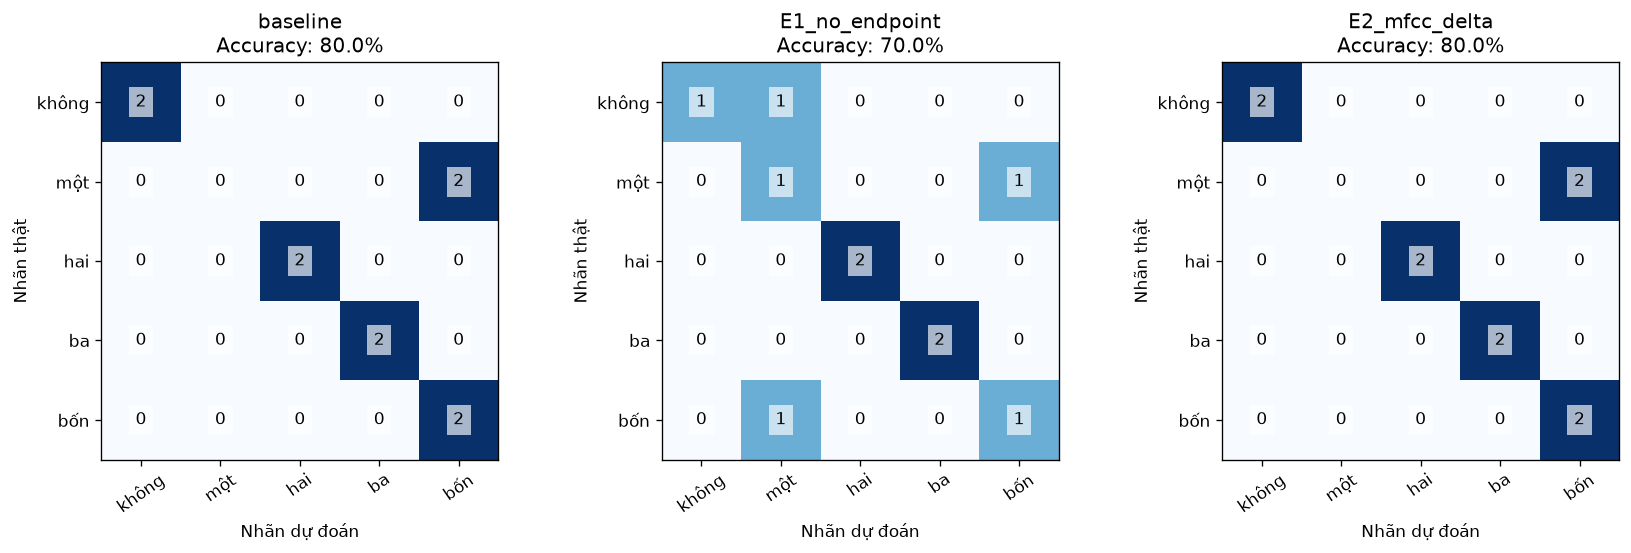

*Hình 11. Ma trận nhầm lẫn của baseline, E1 không endpoint và E2 MFCC + Δ trên cùng 10 file test; trục ngang là nhãn dự đoán, trục dọc là nhãn thật, số trong mỗi ô là số mẫu. Accuracy của từng cấu hình được ghi phía trên mỗi panel.*

Accuracy = số dự đoán đúng / số test. Với 10 test, mỗi lỗi thay đổi 10 điểm phần trăm.
Nhầm có hướng nhiều nhất: một → bốn (2 mẫu)


In [13]:
split, experiments, summaries = run_experiments(DATASET, OUTPUT, CONFIG)
show_table(summaries)
baseline = experiments['baseline']
show_table(baseline['rows'])  # Đủ 10 file test, bao gồm top-3 và score.
show_figure(plot_confusion(experiments, OUTPUT))
print('Accuracy = số dự đoán đúng / số test. Với 10 test, mỗi lỗi thay đổi 10 điểm phần trăm.')
confused = most_confused(baseline['matrix'])
if confused:
    a, b, n = confused
    print('Nhầm có hướng nhiều nhất:', VI_LABELS[a], '→', VI_LABELS[b], f'({n} mẫu)')
else:
    print('Không có lỗi baseline trên tập test này; chưa có cặp nhầm để kết luận.')

### Đối chiếu lỗi giữa các cấu hình

Không kết luận Δ hay trim luôn tốt hơn. Đối chiếu từng file vì hai cấu hình có thể
cùng accuracy nhưng sai các mẫu khác nhau. Với mẫu lỗi, nghe lại và xem biên trim,
MFCC và DTW path trước khi đề xuất nguyên nhân.

| file | true | baseline | E1_no_endpoint | E2_mfcc_delta |
| --- | --- | --- | --- | --- |
| khong/khong_04.wav | khong | khong | mot | khong |
| khong/khong_05.wav | khong | khong | khong | khong |
| mot/mot_04.wav | mot | bon | mot | bon |
| mot/mot_05.wav | mot | bon | bon | bon |
| hai/hai_04.wav | hai | hai | hai | hai |
| hai/hai_05.wav | hai | hai | hai | hai |
| ba/ba_04.wav | ba | ba | ba | ba |
| ba/ba_05.wav | ba | ba | ba | ba |
| bon/bon_04.wav | bon | bon | bon | bon |
| bon/bon_05.wav | bon | bon | mot | bon |

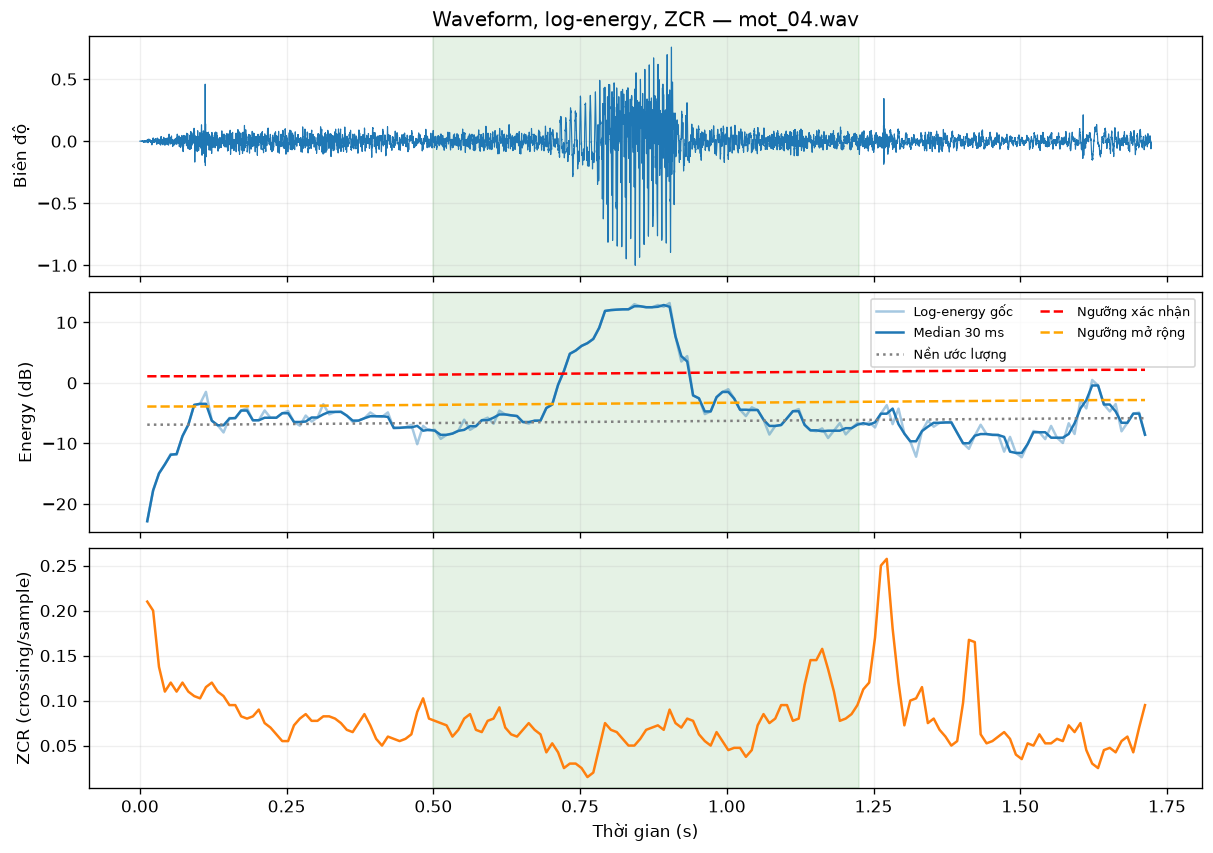

*Hình 12. Waveform, log-energy và ZCR của tệp mot_04.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*

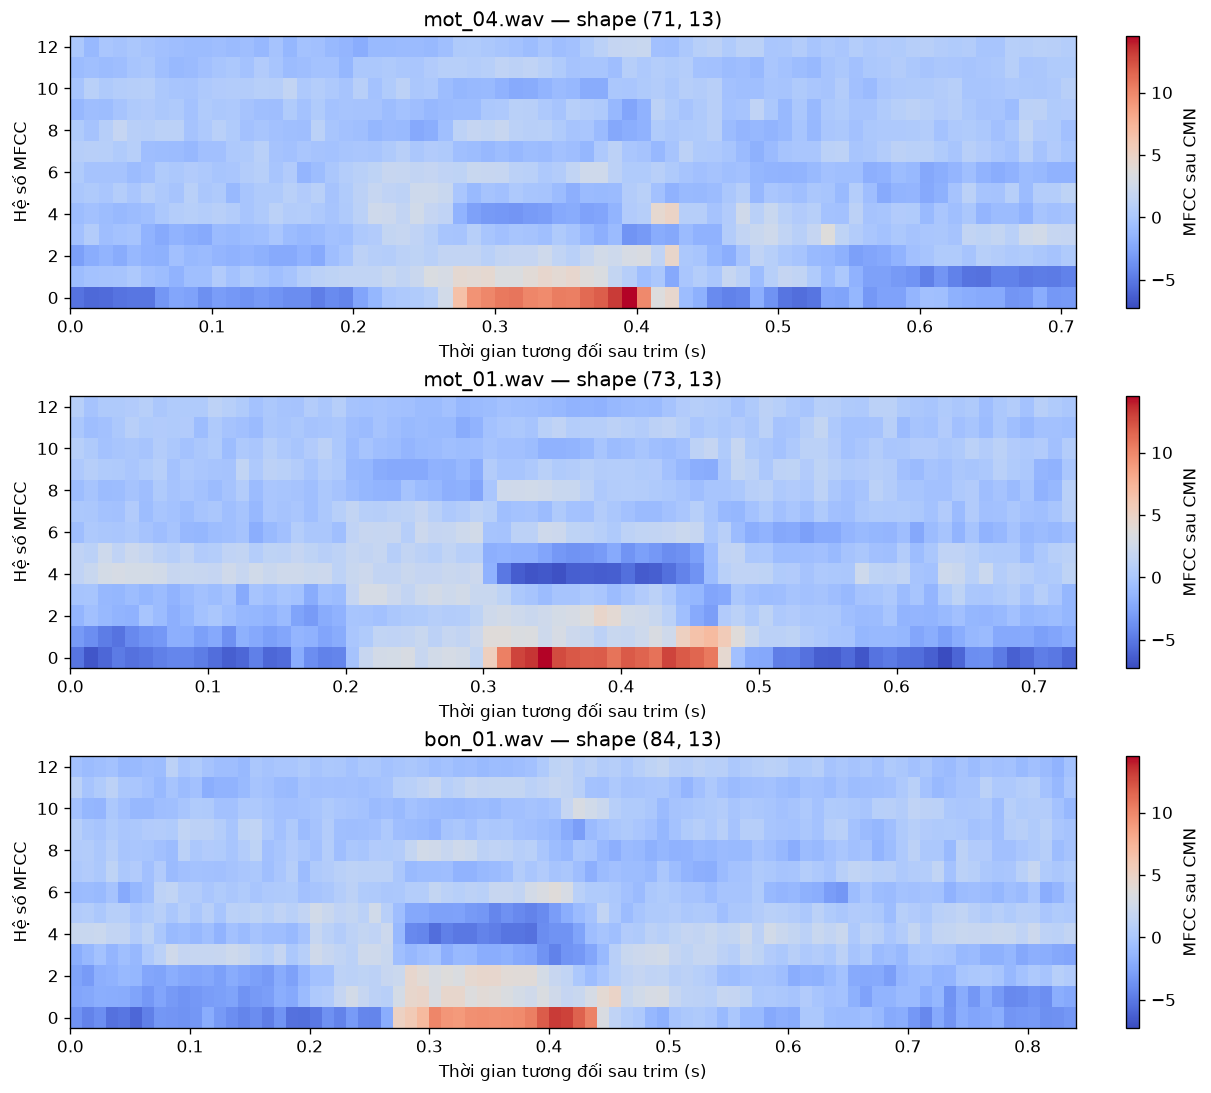

*Hình 13. Heatmap MFCC của các tệp mot_04.wav, mot_01.wav, bon_01.wav; mỗi frame có 13 hệ số và đã chuẩn hóa trung bình cepstral (CMN). Trục ngang là thời gian tương đối sau trim (s), trục dọc là chỉ số hệ số; các panel dùng chung thang màu.*

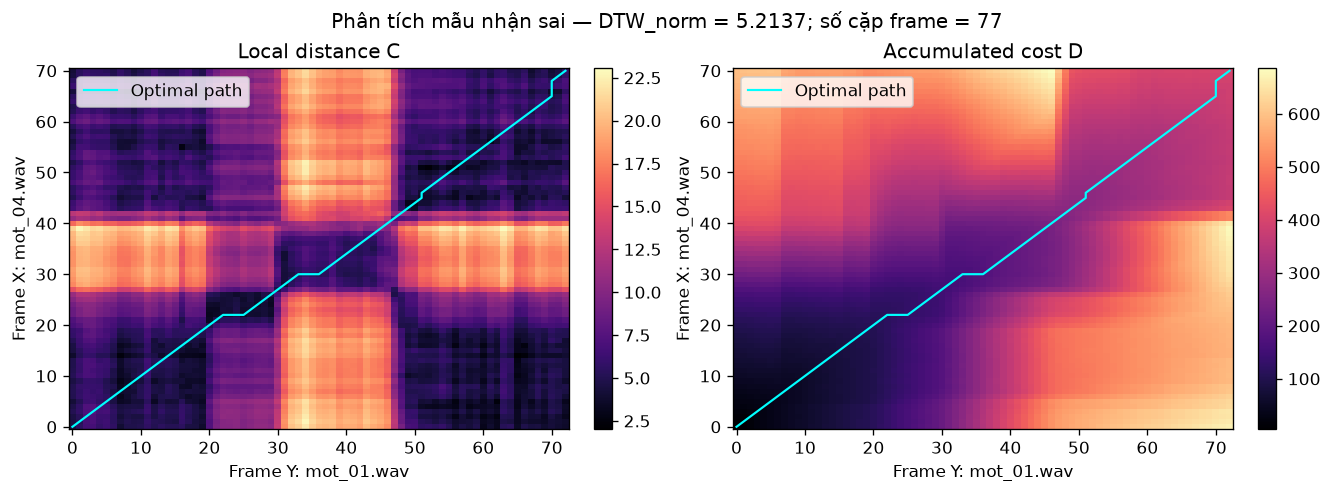

*Hình 14. Hai lần nói cùng từ: căn chỉnh DTW giữa mot_04.wav và mot_01.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*

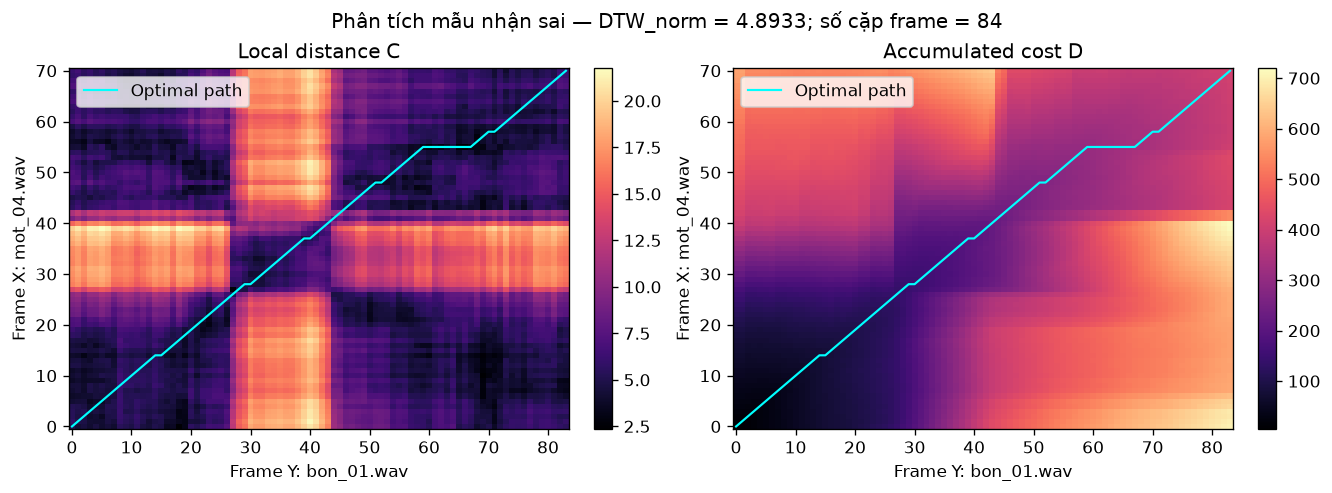

*Hình 15. Hai từ khác nhau: căn chỉnh DTW giữa mot_04.wav và bon_01.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*

In [14]:
comparisons = []
by_config = {name: {row['file']: row for row in result['rows']} for name, result in experiments.items()}
for row in baseline['rows']:
    name = row['file']
    comparisons.append({'file': name, 'true': row['true_label'],
                        **{config: results[name]['predicted_label'] for config, results in by_config.items()}})
show_table(comparisons)

# Tự tạo hình phân tích lỗi baseline nếu có; không bịa cặp nhầm khi accuracy=100%.
for previous_plot in (OUTPUT / 'figures').glob('dtw_error_*.png'):
    previous_plot.unlink()
for paths in split['test'].values():
    for path in paths:
        (OUTPUT / 'figures' / f'time_{path.stem}.png').unlink(missing_ok=True)
first_error = next((r for r in baseline['rows'] if not r['correct']), None)
error_figures = []
if first_error:
    error_path = DATASET / first_error['file']
    fig = plot_time_analysis(error_path, OUTPUT, CONFIG)
    error_figures.append((f'time_{error_path.stem}.png', fig.lab2_caption))
    show_figure(fig)
    fig = plot_mfcc([error_path, split['train'][first_error['true_label']][0],
                     split['train'][first_error['predicted_label']][0]],
                    OUTPUT, CONFIG, name='mfcc_error.png')
    error_figures.append(('mfcc_error.png', fig.lab2_caption))
    show_figure(fig)
    for label in (first_error['true_label'], first_error['predicted_label']):
        refs = split['train'][label]
        best_ref = min(refs, key=lambda p: dtw_distance(extract_feature(error_path, CONFIG),
                                                      extract_feature(p, CONFIG))[0])
        fig, _ = plot_dtw(error_path, best_ref, OUTPUT, 'error_' + label, CONFIG)
        error_figures.append((f'dtw_error_{label}.png', fig.lab2_caption))
        show_figure(fig)
    display(Audio(load_audio(error_path, CONFIG), rate=CONFIG.sr))

## Nhận dạng một WAV chưa biết

Đổi `UNKNOWN_WAV` thành đường dẫn WAV cần nhận dạng. Mặc định dùng một file test,
đã tách khỏi template. Template NPZ lưu cả cấu hình để predict không dùng khác pipeline.

In [15]:
UNKNOWN_WAV = split['test']['khong'][0]  # Ví dụ: ROOT / 'my_word.wav'
saved_templates, saved_config, template_source = load_templates(OUTPUT / 'templates_baseline.npz')
prediction, scores = recognize(UNKNOWN_WAV, saved_templates, saved_config)
print('File:', UNKNOWN_WAV)
print('Nhãn dự đoán:', VI_LABELS[prediction])
print('Khoảng cách DTW:', scores[prediction])
print('Nguồn template:', template_source)
show_table([{'rank': i, 'label': VI_LABELS[label], 'dtw_norm': score}
            for i, (label, score) in enumerate(list(scores.items())[:3], 1)])
display(Audio(load_audio(UNKNOWN_WAV, CONFIG), rate=CONFIG.sr))

File: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet/dataset/khong/khong_04.wav
Nhãn dự đoán: không
Khoảng cách DTW: 4.858885656665763
Nguồn template: phone_recordings


| rank | label | dtw_norm |
| --- | --- | --- |
| 1 | không | 4.8589 |
| 2 | bốn | 5.8285 |
| 3 | một | 5.9048 |

## Báo cáo và sản phẩm nộp

Sinh báo cáo Markdown từ kết quả thực đo, có bảng cấu hình, thời lượng trim,
DTW cùng/khác từ, E1/E2, confusion matrix, giới hạn và trả lời 9 câu hỏi.
Trước khi nộp, bổ sung nhận xét nghe biên trim và mô tả người nói/micro/môi trường thu.
Phần báo cáo trong notebook và file Markdown đáp ứng lựa chọn báo cáo của đề.

In [16]:
report_path = write_report(DATASET, OUTPUT, split, experiments, summaries,
                           quality, endpoint_rows, pair_rows, pitch_result, error_figures)
print('Báo cáo:', report_path)
print('Baseline CSV:', OUTPUT / 'results.csv')
print('Thí nghiệm:', OUTPUT / 'experiments.csv')
print('Hình:', OUTPUT / 'figures')
report_text = report_path.read_text(encoding='utf-8')
display(Markdown(report_text))

Báo cáo: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet/report_Lab02.md
Baseline CSV: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet/results.csv
Thí nghiệm: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet/experiments.csv
Hình: /home/viet/projects/TLU/XuLyAmThanh/ThucHanh/Lab02_2351260695_LoAnhViet/figures


# Lab 2 — Đặc trưng tiếng nói và nhận dạng bằng DTW

**Sinh viên:** Lỗ Anh Việt — **MSSV:** 2351260695

## 1. Dữ liệu và phạm vi kết quả

Dữ liệu WAV do người dùng cung cấp. Cần ghi rõ người nói, thiết bị và môi trường thu trong báo cáo.

Bộ dữ liệu: `dataset`; 5 lớp, 25 file; 15 template và 10 test.

Chia theo tên file đã sắp xếp: 3 file đầu/lớp là train, phần còn lại là test. Danh sách được lưu ở `split.json`; dùng cùng split cho baseline, E1 và E2.

File có mẫu gần clipping (|x| ≥ 0,999): 0. File đúng WAV mono PCM 16 kHz ban đầu: 25/25. Pipeline chuyển mono và resample khi cần; bảng kiểm tra trong notebook dùng dữ liệu trước chuẩn hóa.

## 2. Cấu hình và thuật toán

| Tham số | Giá trị |
|---|---|
| sr | 16000 |
| frame | 400 |
| hop | 160 |
| n_fft | 512 |
| n_mels | 24 |
| n_mfcc | 13 |
| alpha | 0.97 |
| top_db | 35.0 |
| endpoint_method | adaptive |
| noise_window_ms | 200.0 |
| noise_on_db | 8.0 |
| noise_off_db | 3.0 |
| smooth_ms | 30.0 |
| min_speech_ms | 40.0 |
| max_gap_ms | 80.0 |
| margin_ms | 200.0 |
| endpoint | True |
| delta | False |
| cmn | True |

Frame 400 mẫu, hop 160 mẫu, Hamming; frame cuối thiếu mẫu được zero-pad. FFT được padding riêng lên 512. Mel dùng 1125 ln(1+f/700), 24 bộ lọc tam giác. DCT-II trực chuẩn, giữ c0–c12; CMN theo từng utterance. Khoảng cách Euclid, DTW ba bước; tối ưu tổng chi phí rồi chia độ dài path.

## 3. Energy, ZCR, endpoint và autocorrelation

Energy/RMS đo mức biên độ; ZCR đếm đổi dấu trên cửa sổ chữ nhật. Silence thường có energy thấp; voiced thường có energy cao và ZCR thấp hơn unvoiced. ZCR cao cũng có thể do nhiễu nên không dùng riêng làm điều kiện xác định speech.


![Waveform, log-energy và ZCR của tệp khong_01.wav](figures/time_khong_01.png)

*Hình 1. Waveform, log-energy và ZCR của tệp khong_01.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*


![Waveform, log-energy và ZCR của tệp hai_01.wav](figures/time_hai_01.png)

*Hình 2. Waveform, log-energy và ZCR của tệp hai_01.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*


![Waveform, log-energy và ZCR của tệp ba_01.wav](figures/time_ba_01.png)

*Hình 3. Waveform, log-energy và ZCR của tệp ba_01.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*


Endpoint `adaptive` ước lượng nền bằng median log-energy ở 200 ms đầu/cuối, nội suy nền theo thời gian để theo thay đổi gain chậm. Làm trơn median 30 ms; ngưỡng xác nhận = nền + 8 dB, ngưỡng mở rộng = nền + 3 dB. Cần ít nhất 40 ms liên tiếp trên ngưỡng xác nhận; nối khoảng ngắt ≤ 80 ms, chọn vùng có đỉnh tương phản nền lớn nhất. Giữ margin 200 ms mỗi phía; chưa dùng ZCR tinh chỉnh. Xem/nghe các file khong và hai đã trim để kiểm tra phụ âm năng lượng thấp. Không thể kết luận giữ đủ phụ âm chỉ từ thời lượng.

| File | Trước (s) | Sau (s) |
|---|---:|---:|
| khong/khong_01.wav | 1.667 | 1.125 |
| khong/khong_02.wav | 1.900 | 1.365 |
| khong/khong_03.wav | 2.057 | 1.265 |
| mot/mot_01.wav | 1.844 | 0.745 |
| mot/mot_02.wav | 1.750 | 0.755 |
| mot/mot_03.wav | 1.852 | 0.955 |
| hai/hai_01.wav | 2.154 | 1.015 |
| hai/hai_02.wav | 1.738 | 0.955 |
| hai/hai_03.wav | 2.047 | 0.925 |
| ba/ba_01.wav | 2.400 | 0.955 |
| ba/ba_02.wav | 1.733 | 0.885 |
| ba/ba_03.wav | 1.823 | 1.015 |
| bon/bon_01.wav | 1.922 | 0.855 |
| bon/bon_02.wav | 2.033 | 1.395 |
| bon/bon_03.wav | 2.300 | 1.710 |
| khong/khong_04.wav | 1.786 | 0.955 |
| khong/khong_05.wav | 2.400 | 0.975 |
| mot/mot_04.wav | 1.724 | 0.725 |
| mot/mot_05.wav | 1.976 | 0.795 |
| hai/hai_04.wav | 2.029 | 1.225 |
| hai/hai_05.wav | 2.370 | 0.975 |
| ba/ba_04.wav | 2.143 | 1.205 |
| ba/ba_05.wav | 1.899 | 1.005 |
| bon/bon_04.wav | 1.870 | 1.075 |
| bon/bon_05.wav | 2.000 | 0.805 |

Với cấu hình này, 0/25 file giữ nguyên thời lượng sau endpoint.

Đã cắt nền ở 25/25 file; thời lượng loại bỏ trung bình 0.950 s/file. Có 0 file fallback giữ nguyên do chưa xác nhận được speech/clip quá ngắn.

So sánh trực tiếp với endpoint cũ (đỉnh trừ 35 dB, margin 50 ms) trong bảng endpoint của notebook và cột `relative_35db_after_s` ở `endpoint.csv`. Tham số endpoint mới được chọn bằng kiểm tra biên trên 15 file train; giữ cố định trước khi chạy đánh giá 10 file test. Điểm test không dùng để chọn ngưỡng.

![So sánh waveform trước và sau endpoint của tệp khong_01.wav](figures/endpoint_khong_01.png)

*Hình 4. So sánh waveform trước và sau endpoint của tệp khong_01.wav; hai vạch đỏ đánh dấu biên cắt, giữ đệm 200 ms mỗi phía. Panel trên là tín hiệu gốc, panel dưới là đoạn đã cắt với gốc thời gian mới; trục ngang là thời gian (s), trục dọc là biên độ chuẩn hóa.*


![So sánh waveform trước và sau endpoint của tệp hai_01.wav](figures/endpoint_hai_01.png)

*Hình 5. So sánh waveform trước và sau endpoint của tệp hai_01.wav; hai vạch đỏ đánh dấu biên cắt, giữ đệm 200 ms mỗi phía. Panel trên là tín hiệu gốc, panel dưới là đoạn đã cắt với gốc thời gian mới; trục ngang là thời gian (s), trục dọc là biên độ chuẩn hóa.*


Autocorrelation minh họa: file ba_01.wav, lag 154 mẫu, F0 ≈ 103.9 Hz, đỉnh chuẩn hóa 0.252. Ước lượng trên frame energy lớn nhất trong miền 70–400 Hz; có thể nhầm bội/ước pitch, không dùng pitch làm đầu vào recognizer.


![Frame có energy lớn nhất của tệp ba_01.wav và tự tương quan ngắn hạn](figures/autocorrelation.png)

*Hình 6. Frame có energy lớn nhất của tệp ba_01.wav và tự tương quan ngắn hạn; panel trái biểu diễn frame đã bỏ DC và nhân Hamming theo thời gian (ms), panel phải biểu diễn R[k]/R[0] theo lag (mẫu). Tìm đỉnh trong miền 70–400 Hz, lag 154 mẫu cho F0 xấp xỉ 103.9 Hz.*

## 4. MFCC và DTW

Mỗi frame luôn có 13 hệ số; số frame phụ thuộc độ dài từ sau trim. Cấu trúc màu theo thời gian của heatmap phản ánh biến thiên đường bao phổ.


![Mel filterbank gồm 24 bộ lọc tam giác tại Fs = 16 kHz và NFFT = 512](figures/mel_filterbank.png)

*Hình 7. Mel filterbank gồm 24 bộ lọc tam giác tại Fs = 16 kHz và NFFT = 512; trục ngang là tần số (Hz), trục dọc là trọng số. Khoảng cách theo Hz giữa các bộ lọc tăng dần ở vùng tần số cao.*


![Heatmap MFCC của các tệp khong_01.wav, ba_01.wav](figures/mfcc_comparison.png)

*Hình 8. Heatmap MFCC của các tệp khong_01.wav, ba_01.wav; mỗi frame có 13 hệ số và đã chuẩn hóa trung bình cepstral (CMN). Trục ngang là thời gian tương đối sau trim (s), trục dọc là chỉ số hệ số; các panel dùng chung thang màu.*


| Cặp so sánh | Frames X/Y | Path length | DTW_norm |
|---|---:|---:|---:|
| same_word | 111/135 | 143 | 7.8919 |
| different_word | 111/94 | 113 | 7.8620 |

Ở cặp minh họa này, score cùng từ lớn hơn hoặc bằng score khác từ. Do đó không thể dùng riêng hai cặp này để kết luận cùng từ luôn gần hơn. Nên kiểm tra biến thiên phát âm, vùng nền và biên speech; không tự thay cặp minh họa hoặc chọn lại split để làm đẹp kết quả.

![Hai lần nói cùng từ: căn chỉnh DTW giữa khong_01.wav và khong_02.wav](figures/dtw_same_word.png)

*Hình 9. Hai lần nói cùng từ: căn chỉnh DTW giữa khong_01.wav và khong_02.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*


![Hai từ khác nhau: căn chỉnh DTW giữa khong_01.wav và ba_01.wav](figures/dtw_different_word.png)

*Hình 10. Hai từ khác nhau: căn chỉnh DTW giữa khong_01.wav và ba_01.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*


Hai chuỗi có độ dài khác nhau nên đường đi có thể lệch đường chéo hình học. Bước ngang/dọc biểu diễn kéo giãn theo thời gian; không bảo đảm mọi cặp cùng từ đều có chi phí nhỏ hơn mọi cặp khác từ.

## 5. Nhận dạng và thí nghiệm E1–E2

Mỗi nhãn lấy khoảng cách nhỏ nhất trong 3 template; chọn nhãn có score thấp nhất. Top-3 là ba nhãn, không phải ba template. Không áp dụng reject unknown.

| Thí nghiệm | Endpoint | Số chiều | Đúng/test | Accuracy |
|---|---|---:|---:|---:|
| baseline | True | 13 | 8/10 | 80.0% |
| E1_no_endpoint | False | 13 | 7/10 | 70.0% |
| E2_mfcc_delta | True | 26 | 8/10 | 80.0% |

Đối chiếu với lần chạy endpoint cũ trên cùng WAV/split và cấu hình MFCC:

| Cấu hình | Endpoint cũ | Endpoint mới | Thay đổi (điểm %) |
|---|---:|---:|---:|
| baseline | 70.0% | 80.0% | +10.0 |
| E1_no_endpoint | 70.0% | 70.0% | +0.0 |
| E2_mfcc_delta | 90.0% | 80.0% | -10.0 |

Trim loại vùng nền làm thay đổi MFCC, CMN và Δ theo thời gian. Giảm thời lượng không bảo đảm mọi cấu hình nhận dạng đều tốt hơn; giữ nguyên các kết quả tăng/giảm và không chọn lại ngưỡng bằng test. `endpoint_reference.json` lưu số đo cũ và hash WAV; chỉ tạo bảng đối chứng khi dữ liệu và cấu hình feature còn khớp.

E1 bỏ endpoint: accuracy thay đổi -10.0 điểm phần trăm so với baseline. E2 thêm Δ: thay đổi +0.0 điểm phần trăm. Feature được tính lại cho cả template và test trong từng cấu hình; E2 dùng đạo hàm Savitzky–Golay qua Librosa, cửa sổ tối đa 9 frame.

Cùng accuracy không đồng nghĩa cùng dự đoán; đối chiếu results_all.csv. Tập test nhỏ nên chưa đủ suy rộng về độ chính xác trên người nói mới.


![Ma trận nhầm lẫn của baseline, E1 không endpoint và E2 MFCC + Δ trên cùng 10 file test](figures/confusion_matrix.png)

*Hình 11. Ma trận nhầm lẫn của baseline, E1 không endpoint và E2 MFCC + Δ trên cùng 10 file test; trục ngang là nhãn dự đoán, trục dọc là nhãn thật, số trong mỗi ô là số mẫu. Accuracy của từng cấu hình được ghi phía trên mỗi panel.*

Nhầm có hướng nhiều nhất: **một → bốn**, 2 mẫu. Cần nghe lại, kiểm tra biên trim và đối chiếu waveform/MFCC/path; chưa thể khẳng định nguyên nhân chỉ từ confusion matrix.

| File lỗi | Nhãn thật | Dự đoán | Top-1 score |
|---|---|---|---:|
| mot/mot_04.wav | mot | bon | 4.8933 |
| mot/mot_05.wav | mot | bon | 4.8275 |

Các hình dưới phân tích mẫu lỗi đầu tiên: waveform/energy/ZCR, MFCC so với hai nhãn và DTW tới template gần nhất của từng nhãn.

![Waveform, log-energy và ZCR của tệp mot_04.wav](figures/time_mot_04.png)

*Hình 12. Waveform, log-energy và ZCR của tệp mot_04.wav; tín hiệu mono 16 kHz, frame 25 ms, hop 10 ms. Ba panel lần lượt là biên độ chuẩn hóa, log-energy (dB) cùng mức nền/ngưỡng endpoint, và ZCR (crossing/sample); trục ngang là thời gian (s), vùng xanh là đoạn được giữ lại.*


![Heatmap MFCC của các tệp mot_04.wav, mot_01.wav, bon_01.wav](figures/mfcc_error.png)

*Hình 13. Heatmap MFCC của các tệp mot_04.wav, mot_01.wav, bon_01.wav; mỗi frame có 13 hệ số và đã chuẩn hóa trung bình cepstral (CMN). Trục ngang là thời gian tương đối sau trim (s), trục dọc là chỉ số hệ số; các panel dùng chung thang màu.*


![Hai lần nói cùng từ: căn chỉnh DTW giữa mot_04.wav và mot_01.wav](figures/dtw_error_mot.png)

*Hình 14. Hai lần nói cùng từ: căn chỉnh DTW giữa mot_04.wav và mot_01.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*


![Hai từ khác nhau: căn chỉnh DTW giữa mot_04.wav và bon_01.wav](figures/dtw_error_bon.png)

*Hình 15. Hai từ khác nhau: căn chỉnh DTW giữa mot_04.wav và bon_01.wav; panel trái là ma trận khoảng cách Euclid cục bộ C, panel phải là chi phí tích lũy D. Đường xanh cyan là đường đi tối ưu; trục ngang là chỉ số frame Y, trục dọc là chỉ số frame X. DTW_norm và số cặp frame trên đường đi được ghi trên hình.*


## 6. Trả lời câu hỏi báo cáo

1. Waveform nhạy với pha, tốc độ nói và số mẫu. MFCC mô tả đường bao phổ; DTW căn chỉnh chuỗi frame có độ dài khác nhau, phù hợp hơn so khớp mẫu thô.

2. Energy xác định vùng có mức tín hiệu đáng kể; ZCR hỗ trợ phân biệt hữu thanh/vô thanh và xem xét phụ âm yếu ở biên. Nhiễu có thể có ZCR cao nên cần phối hợp và nghe kiểm tra.

3. Thang Mel có độ dốc giảm khi Hz tăng; các điểm cách đều theo Mel sẽ cách xa hơn theo Hz ở vùng tần số cao.

4. Log nén dynamic range và biến quan hệ nhân thành cộng. DCT biểu diễn log-energy Mel bằng các hệ số cepstral; hệ số thấp mô tả biến thiên phổ chậm/đường bao phổ.

5. Với trục ngang Y và dọc X: bước ngang giữ frame X, tiến Y; bước dọc tiến X, giữ Y; bước chéo tiến cả hai. Các bước cho phép một frame ghép nhiều frame chuỗi kia.

6. Tổng cost thường tăng khi path dài. Chia path length giảm thiên lệch chiều dài; đây là chuẩn hóa sau khi tối ưu tổng, không phải tối ưu cost trung bình.

7. Tốc độ/phát âm, pitch và trạng thái giọng, mức âm lượng/khoảng cách micro, tiếng ồn/kênh thu, và vị trí biên trim đều có thể làm MFCC thay đổi.

8. Xem cặp nhầm ở mục 5. Kiểm tra audio và hình trước khi quy nguyên nhân; nếu không có lỗi thì báo không có cặp nhầm trên tập hiện tại, không tự tạo kết luận.

9. Template ít người không bao phủ biến thiên người nói. HMM và mô hình âm học được huấn luyện trên dữ liệu nhiều người có thể mô hình hóa biến thiên theo thời gian và người nói tốt hơn; hiệu quả còn phụ thuộc dữ liệu huấn luyện.

## 7. Giới hạn và việc cần hoàn thiện

Chưa có thí nghiệm cross-speaker, chưa hiệu chỉnh ngưỡng reject. Endpoint giả định 200 ms đầu/cuối chủ yếu là nền, và một file có một từ. Tiếng người khác kéo dài hoặc nền thay đổi đột ngột vẫn có thể làm sai biên. Chỉ chọn tham số trên train/validation; giữ test làm đánh giá cuối. Trước khi nộp cần nghe biên trim và bổ sung mô tả thu âm.
